# Import Libraries

In [1]:
#import cac thu vien
import numpy as np  # giup lam viec voi du lieu dang mang
import pandas as pd # giup lam viec voi du lieu dang bang
import matplotlib.pyplot as plt # giup ve do thi
import seaborn as sns # giup ve do thi dep hon

# Load Dataset

In [6]:
# Doc du lieu bang pandas, dang dataframe
path = "Bangalore_House_Price_data/Bengaluru_House_Data.csv"
df_raw = pd.read_csv(path) # doc du lieu tu file csv bang pandas

# Sau khi doc xong, df_raw se la mot dataframe, co dang bang, co cac cot va hang. De xem so cot va hang, ta dung lenh shape

df_raw.shape

(13320, 9)

In [7]:
# Preview 5 sample dau tien
df_raw.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [8]:
# Review 5 sample cuoi cung
df_raw.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


# Exploratory Data Analysis (EDA)
Khám phá và hiểu dữ liệu trước khi xây dựng mô hình Machine Learning

In [9]:
df = df_raw.copy() # Tao ban sao de thuc hien EDA

In [ ]:
df.info() # Thong tin co ban

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [11]:
# Thong ke 1 so thuoc tinh co ban cua du lieu (bao gom count, mean, std, min, max, ....)
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [12]:
# Thong ke cac gia tri duy nhat cua tung truong va so lan xuat hien cua chung
def value_count (df):
    for val in df.columns:
        print (df[val].value_counts())
        print("-----------------------------")

value_count(df)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
-----------------------------
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
-----------------------------
location
Whitefield                        540
Sarjapur  Road                    399
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64
-----------------

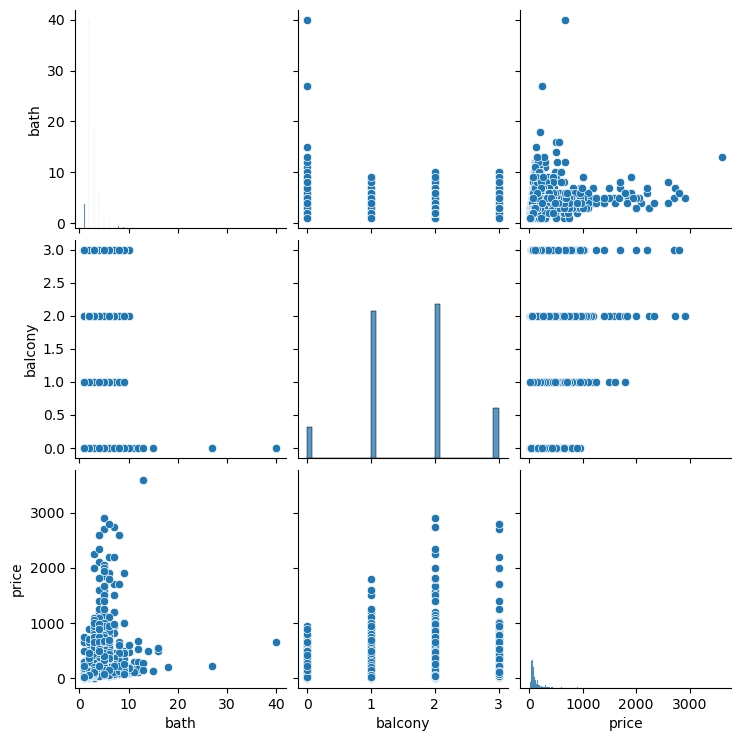

In [13]:
# Xem xet tuong quan ve gia tri cac cap truong so
sns.pairplot(df)

<Axes: >

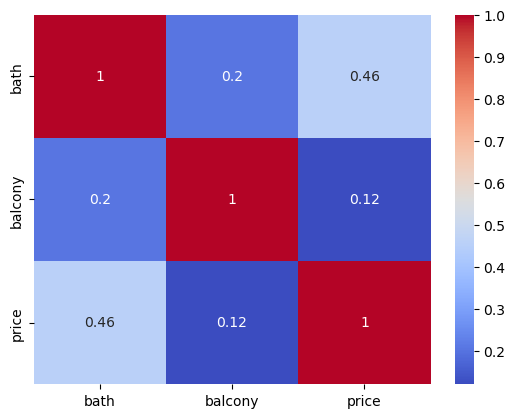

In [14]:
num_vars = ["bath", "balcony",  "price"]
sns.heatmap(df[num_vars].corr(), annot=True, cmap="coolwarm")

<Axes: >

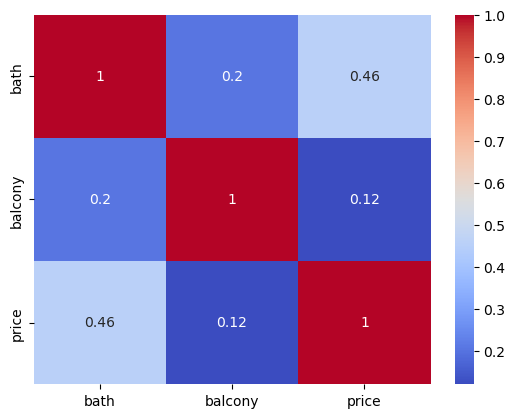

In [15]:
# num_vars = ["bath", "balcony",  "price"]
sns.heatmap(df[num_vars].corr(), annot=True, cmap="coolwarm")

# Prepare Data for Machine Learning Model
Làm sạch dữ liệu trước khi đưa dữ liệu vào machine learning model

#### Data cleaning

In [16]:
# Thong ke so luong gia tri null cua tung thuoc tinh
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [17]:
# Ty le gia tri null cua tung thuoc tinh
df.isnull().mean() * 100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

In [18]:
# Loai di truong society vi ti le null qua cao
df2 = df.drop('society', axis = 'columns')
df2.shape

(13320, 8)

In [19]:
# Thay the gia trij null trong truong balcony bang gia tri trung binh cua cac gia tri not null
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean())
df2.isnull().sum()

area_type        0
availability     0
location         1
size            16
total_sqft       0
bath            73
balcony          0
price            0
dtype: int64

In [20]:
# Xoa di cac diem du lieu (hang) co gia tri nan (khong co gia tri)
df3 = df2.dropna()
df3.shape

(13246, 8)

In [21]:
# Thong ke lai xem da xu ly het cac du lieu null chua
df3.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

### Feature Engineering
Biến đổi hoặc tạo ra các thuộc tính mới từ dữ liệu ban đầu để mô hình Machine Learning học tốt hơn

In [22]:
# Cho phep in ra toan bo cac gia tri output co the cua cau lenh
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [23]:
# Chuan bi chuyen cot total_sqft ve dang so
# Dung value_counts de xem cac gia tri trong cot xuat hien bao nhieu lan
# Giup phat hien cac gia tri bat thuong can xu ly
df3['total_sqft'].value_counts()

total_sqft
1200                 843
1100                 221
1500                 204
2400                 195
600                  180
1000                 172
1350                 132
1050                 123
1300                 117
1250                 114
900                  112
1400                 108
1800                 104
1150                 101
1600                 100
1140                  91
2000                  82
1450                  70
1650                  69
800                   67
3000                  66
1075                  66
1020                  63
2500                  62
1125                  60
1160                  60
1550                  60
950                   59
1700                  58
1180                  58
1260                  57
1255                  56
1080                  55
1220                  55
1070                  53
750                   52
700                   52
4000                  48
1175                  48
1225          

In [ ]:
# Chuyen truong total_sqft thanh kieu float
total_sqft_float = [] # Tao list de luu ket qua chuyen doi
for str_val in df3['total_sqft']:
    try:
        # Neu gia tri la so binh thuong (chang han 1200, 1500) thi co the chuyen truc tiep sang float
        total_sqft_float.append(float(str_val))
    
    # Neu gia tri dang khoang
    except:
        try:
            temp = []
            # Tach 2 so trong khoang bang dau '-'
            temp = str_val.split('-')
            # Tinh trung binh cua 2 so do de thay the cho gia tri khoang
            total_sqft_float.append((float(temp[0]) + float (temp[-1])) / 2)
        except:
            # Dua ra gia tri nan neu khong the chuyen doi duoc
            total_sqft_float.append(np.nan)

In [25]:
df4 = df3.reset_index(drop = True) # Tao ban sao de thuc hien EDA

In [28]:
# Them cot total_sqft_float (da xu ly thanh so) vao dataframe df4, roi xem 5 dong dau cua bang du lieu moi
df5 = df4.join(pd.DataFrame({'total_sqft_float': total_sqft_float}))
df5.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0


In [29]:
# Thong tin ve so diem du lieu null cua tung truong
df5.isnull().sum()

area_type            0
availability         0
location             0
size                 0
total_sqft           0
bath                 0
balcony              0
price                0
total_sqft_float    46
dtype: int64

In [30]:
# Bo di cac diem du lieu (hang) co gia tri null
df6 = df5.dropna()
df6.shape

(13200, 9)

In [31]:
# Xem lai thong tin cua dataframe
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13245
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13200 non-null  object 
 1   availability      13200 non-null  object 
 2   location          13200 non-null  object 
 3   size              13200 non-null  object 
 4   total_sqft        13200 non-null  object 
 5   bath              13200 non-null  float64
 6   balcony           13200 non-null  float64
 7   price             13200 non-null  float64
 8   total_sqft_float  13200 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.0+ MB


In [32]:
# Lam viec voi feature: size
df6['size'].value_counts()

size
2 BHK         5192
3 BHK         4277
4 Bedroom      816
4 BHK          574
3 Bedroom      541
1 BHK          527
2 Bedroom      325
5 Bedroom      293
6 Bedroom      190
1 Bedroom      100
7 Bedroom       83
8 Bedroom       83
5 BHK           56
9 Bedroom       45
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            7
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [ ]:
# Chuyen thuoc tinh so phong tu dang category ve dang numeric
size_int = []
for str_val in df6['size']:
    temp = []
    temp = str_val.split(" ")
    try:
        size_int.append(int(temp[0]))
    except:
        size_int.append(np.nan)
        print("Noice = ", str_val)
